In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

from matplotlib.animation import FuncAnimation, PillowWriter

## Funciones auxiliares

In [2]:
# Algoritmos para la factorización de matrices y sustitución progresiva y regresiva
# ------ Factorización LU ------
def matrix_factorization_nxn(
    diagonal: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal inferior)
):
    """
    Función para realizar la factorización de una matriz tridiagonal A = L*U
    donde L es una matriz triangular inferior con 1's en la diagonal principal y
    U es una matriz triangular superior.
    Parámetros:
    diagonal : np.array
        Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal inferior)
    Retorna:
    l_diag : np.array
        Vector que contiene los coeficientes de la matriz L (diagoanl)
    l_diag_inf : np.array
        Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    u_diag_sup : np.array
        Vector que contiene los coeficientes de la matriz U (diagonal)
    """
    l_diag = np.zeros(len(diagonal))
    l_diag_inf = np.zeros(len(diagonal_inferior))
    u_diag_sup = np.zeros(len(diagonal_superior))

    l_diag[0] = diagonal[0]
    l_diag_inf = diagonal_inferior.copy()
    for i in range(0, len(diagonal_superior)):
        u_diag_sup[i] = diagonal_superior[i] / l_diag[i]
        l_diag[i + 1] = diagonal[i + 1] - l_diag_inf[i] * u_diag_sup[i]

    return l_diag, l_diag_inf, u_diag_sup


# ------ Algoritmos para la sustitución progresiva y regresiva ------
# === Sustirución Regresiva ===
# Solución del sistema Ux = z
def sustitucion_regresiva(
    u_diagonal_superior: np.array,  # Vector que contiene los coeficientes de la matriz U (diagonal superior)
    termino_independiente: np.array,  # Vector que contiene los términos independientes
):
    x = np.zeros(len(termino_independiente))
    x[-1] = termino_independiente[-1]
    for i in range(len(termino_independiente) - 2, -1, -1):  # de n-2 hasta 0
        x[i] = termino_independiente[i] - u_diagonal_superior[i] * x[i + 1]

    return x


# === Sustitución Progresiva ===
# Solución del sistema Lz = b
def sustitucion_progresiva(
    l_diagonal: np.array,  # Vector que contiene los coeficientes de la matriz L (diagonal)
    l_diagonal_inferior: np.array,  # Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    termino_independiente: np.array,  # Vector que contiene los términos independientes
):
    z = np.zeros(len(termino_independiente))
    z[0] = termino_independiente[0] / l_diagonal[0]
    for i in range(1, len(termino_independiente)):
        z[i] = (
            termino_independiente[i] - l_diagonal_inferior[i - 1] * z[i - 1]
        ) / l_diagonal[i]

    return z


class Esquema(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def calcular_esquema(self):
        pass


def animar_esquema(esquema, a, b, T, filename="animacion_esquema.gif", fps=30):
    """
    Genera y guarda una animación de la evolución temporal del esquema numérico.

    Parámetros
    ----------
    esquema : objeto de clase EsquemaAdelanteCentrado
        Instancia ya configurada del esquema.
    a, b : float
        Límites espaciales del dominio.
    T : float
        Tiempo total de simulación.
    filename : str
        Nombre del archivo GIF (sin extensión).
    fps : int
        Cuadros por segundo para la animación.
    """
    # === 1. Calcular el esquema ===
    V = esquema.calcular_esquema()

    # === 2. Variables espaciales y temporales ===
    x = np.arange(a + esquema.valor_h, b, esquema.valor_h)
    t = np.arange(0, T + esquema.valor_k, esquema.valor_k)

    # Ajustar longitudes en caso de que difieran
    Nt, Nx = V.shape
    if len(t) > Nt:
        t = t[:Nt]

    # === 3. Crear figura ===
    fig, ax = plt.subplots()
    line, = ax.plot(x, V[0, :], color="blue", lw=2)
    ax.set_xlim(a, b)
    ax.set_ylim(np.min(V) * 1.1, np.max(V) * 1.1)
    ax.set_xlabel("x")
    ax.set_ylabel("u(t,x)")
    ax.set_title("Evolución temporal del esquema")
    ax.grid(True)

    # === 4. Función de actualización ===
    def update(frame):
        line.set_ydata(V[frame, :])
        ax.set_title(f"t = {t[frame]:.3f} s")
        return line,

    # === 5. Crear animación ===
    ani = FuncAnimation(fig, update, frames=Nt, interval=1000/fps, blit=True)

    # === 6. Guardar como GIF ===
    ani.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"✅ Animación guardada como: {filename}")


## Solución del problema

In [3]:
# Variables de la parte espacial
a = -1  # Limite inferior del intervalo a evaluar
b = 1  # Limite superior del intervalo a evaluar
# M = 200  # Número de divisiones de la parte espacial

# h = (b - a) / M             # Tamaño de paso: h = (b-a)/M
h = [1 / 10, 1 / 20, 1 / 40, 1 / 80, 1 / 160]
i = 0  # Valor de h para escoger

# Variables de la parte temporal
beta = 0.6
T = 1.2  # Limite superior del intervalo temporal

# N = 2000  # Número de divisones de la parte temporal
# k = T / N  # Tamaño de paso: k = T/N
k1 = beta * h[i]
k2 = beta * h[i] ** 2

k = [k1, k2]
j = 0  # Valor de k para escoger

alpha = -1 / 2  # Constante que acompaña a la derivada espacial
cons_matriz = (alpha * k[j]) / (2 * h[i])

print(f"Valor de h: {h[i]}")
print(f"Valor de k: {k[j]}")
# print(f"Valores de la variable espacial x: {x}, con {len(x)} puntos")
# print(f"Valores de la variable temporal t: {t}, con {len(t)} puntos")


Valor de h: 0.1
Valor de k: 0.06


In [4]:
# Definición de la solución del PVI
def solucion(t, x):
    fun = (1 - 1 / 2 * t) * np.exp(-(x**2))
    return fun

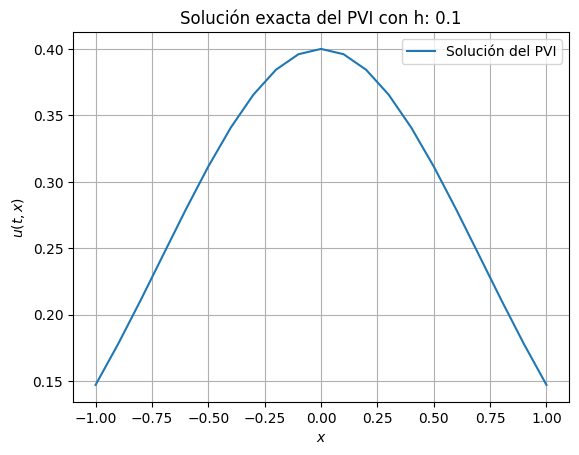

In [5]:
# Visualizar la función
sol = solucion(1.2, np.arange(a, b + h[i], h[i]))

plt.plot(np.arange(a, b + h[i], h[i]), sol, label="Solución del PVI")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$u(t,x)$")
plt.title(f"Solución exacta del PVI con h: {h[i]}")
plt.grid()
plt.show()

## Esquema implícito adelante en tiempo - centrado en espacio

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m+1}^{n+1} - V_{m-1}^{n+1}}{2h} = \frac{f_{m+1}^{n} + f_{m-1}^{n}}{2}$


In [6]:
# Condicion inicial
def condicion_inicial(x):
    fun = np.exp(-(x**2))
    return fun


def f(t, x):
    fun = np.exp(-(x**2)) * (x - 1 / 2 * x * t - 1 / 2)
    return fun

In [7]:
class EsquemaAdelanteCentrado(Esquema):
    def __init__(
        self,
        valor_h,
        valor_k,
        constante_matriz,
    ):
        self.valor_h = valor_h
        self.valor_k = valor_k
        self.constante_matriz = constante_matriz

    def calcular_esquema(self):
        # Cantidad de puntos en la parte espacial
        M = (b - a) / self.valor_h
        N = T / self.valor_k
        #print(f"Valor de M. {M}")
        #print(f"Valor de N. {N}")

        # Definicion de las variables espaciales y temporales
        x = np.arange(a + self.valor_h, b, self.valor_h)
        t = np.arange(0, T + self.valor_k, self.valor_k)
        #print(f"Dimensión de x: {x.shape}")
        # Definición de la matriz tridiagonal A
        diag = np.ones(len(x))                                          # Diagonal principal
        diag_inf = np.zeros(len(x) - 1) - self.constante_matriz         # Diagonal inferior
        diag_sup = np.zeros(len(x) - 1) + self.constante_matriz         # Diagonal superior

        # Factorización de la matriz
        diag_L, diag_inf_L, diag_sup_U = matrix_factorization_nxn(
            diagonal=diag, diagonal_superior=diag_sup, diagonal_inferior=diag_inf
        )

        # Matriz para guardar los resultados
        V = np.zeros((int(N) + 1, int(M) - 1))

        # Condiciones de frontera
        cond_iniciales = condicion_inicial(x)

        # Guardo las condiciones iniciales en la primera fila de V
        V[0, :] = cond_iniciales

        for i in range(1, int(N) - 1):
            # Construcción del vector F
            f1 = []
            f2 = []
            for j in range(0, int(M) - 1):

                f1.append(self.valor_k * f(t[i - 1], x[j]))
                if j == len(x) - 1:
                    f2.append(0)
                    break
                f2.append(self.valor_k * f(t[i - 1], x[j + 1]))
            F = (np.array(f1) + np.array(f2)) / 2

            # Definición de la condición de frontera inferior
            condicion_frontera_inf = self.constante_matriz * solucion(t[i], -1)
            # Definición de la condición de frontera superior
            condicion_frontera_sup = self.constante_matriz * solucion(t[i], 1)

            # Adición del valor en la frontera
            F[0] += condicion_frontera_inf
            F[-1] -= condicion_frontera_sup
            #F = np.insert(F, 0, condicion_frontera_inf)
            #F = np.append(F, -condicion_frontera_sup)

            #print(f"Dimensión de F: {F.shape}")
            #print(f"Dimensión de V[i-1,:]: {V[i - 1, :].shape}")

            # Valores anteriores
            V_anterior = V[i - 1, :] + F

            # ===== Solución del sistema Ax = b =====
            
            # Aplicación de la sustitución regresiva
            z = sustitucion_regresiva(
                u_diagonal_superior=diag_sup_U, termino_independiente=V_anterior
            )

            # Aplicación de la sustitución progresiva
            V[i, :] = sustitucion_progresiva(
                l_diagonal=diag_L,
                l_diagonal_inferior=diag_inf_L,
                termino_independiente=z,
            )

        return V

In [8]:
esquema = EsquemaAdelanteCentrado(
    valor_h=h[i],
    valor_k=k[j],
    constante_matriz=cons_matriz,
)

name_esquema = f"Esquema adelante tiempo - centrado espacio h={h[i]} - k={k[j]}"
N = int(T / k[j])

animar_esquema(
    esquema=esquema,
    a=-1,
    b=1,
    T=1.2,
    filename=name_esquema + ".gif",
    fps=20
)

✅ Animación guardada como: Esquema adelante tiempo - centrado espacio h=0.1 - k=0.06.gif


# Error

In [11]:
print("=" * 80)
print("SOLUCIÓN NUMÉRICA - ESQUEMA FTCS IMPLÍCITO")
print("=" * 80)
print(f"\nParámetros: T = {T}, β = {beta}")
print("Solución exacta: u(t,x) = (1 - t/2) * exp(-x²)")
print("\n" + "=" * 80)

h_values_linear = [1 / 10, 1 / 20, 1 / 40, 1 / 80, 1 / 160]
h_values_text = ["1/10", "1/20", "1/40", "1/80", "1/160"]
errors_linear = []


def error(h, u_numeric, u_exact):
    return np.sqrt(h * np.sum(np.abs(u_exact - u_numeric) ** 2))


def compute_order(error1, error2):
    """Compute convergence order"""
    if error1 == 0 or error2 == 0:
        return 0
    return np.log(error1 / error2) / np.log(2)


# Table 1: k = O(h) - Linear relationship
print("\n\nTABLA 1: k = β*h (relación lineal)")
print("-" * 80)
print(f"{'O(h)':^15} | {'Error':^20} \t\t| {'Orden':^20}")
print("-" * 80)

for i, h in enumerate(h_values_linear):
    k = beta * h
    x = np.arange(a, b, h)
    esquema = EsquemaAdelanteCentrado(
        valor_h=h,
        valor_k=k,
        constante_matriz=(alpha * k) / (2 * h),
    )
    error_tn = error(h, esquema.calcular_esquema()[-1, :], solucion(T, x[0:-1]))
    errors_linear.append(error_tn)

    if i == 0:
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {'-':^20}")
    else:
        order = compute_order(errors_linear[i], errors_linear[i - 1])
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {order:^20.6f}")

    # name_esquema = f"Esquema adelante tiempo - centrado espacio h={h} - k={k}"
    # cond_iniciales = condicion_inicial(x[0:-1])
    # N = int(T / k)

    # animar_esquema(
    #     esquema=esquema,
    #     a=-1,
    #     b=1,
    #     T=1.2,
    #     filename=name_esquema + ".gif",
    #     fps=20
    # )

SOLUCIÓN NUMÉRICA - ESQUEMA FTCS IMPLÍCITO

Parámetros: T = 1.2, β = 0.6
Solución exacta: u(t,x) = (1 - t/2) * exp(-x²)



TABLA 1: k = β*h (relación lineal)
--------------------------------------------------------------------------------
     O(h)       |        Error         		|        Orden        
--------------------------------------------------------------------------------
1/10 		|   4.3369971452e-01   		|          -          
1/20 		|   4.3595206514e-01   		|       0.007473      
1/40 		|   4.3680605886e-01   		|       0.002823      
1/80 		|   4.3717201115e-01   		|       0.001208      
1/160 		|   4.3734056268e-01   		|       0.000556      


In [10]:
# Table 2: k = O(h^2) - Quadratic relationship
print("\n\nTABLA 2: k = β*h² (relación cuadrática)")
print("-" * 80)
print(f"{'O(h²)':^15} | {'Error':^20} \t\t| {'Orden':^20}")
print("-" * 80)

for i, h in enumerate(h_values_linear):
    x = np.arange(a + h, b, h)
    k = beta * h**2
    esquema = EsquemaAdelanteCentrado(
        valor_h=h,
        valor_k=k,
        constante_matriz=(alpha * k) / (2 * h),
    )
    error_tn = error(h, esquema.calcular_esquema()[-1, :], solucion(T, x))
    errors_linear.append(error_tn)

    if i == 0:
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {'-':^20}")
    else:
        order = compute_order(errors_linear[i], errors_linear[i - 1])
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {order:^20.6f}")



TABLA 2: k = β*h² (relación cuadrática)
--------------------------------------------------------------------------------
     O(h²)      |        Error         		|        Orden        
--------------------------------------------------------------------------------
1/10 		|   4.3485222436e-01   		|          -          
1/20 		|   4.3621934446e-01   		|       0.007473      
1/40 		|   4.3687036867e-01   		|       0.002823      
1/80 		|   4.3718778117e-01   		|       0.001208      
1/160 		|   4.3734446716e-01   		|       0.000556      
